Importing plotly failed. Interactive plots will not work.
17:25:49 - cmdstanpy - INFO - Chain [1] start processing
17:25:49 - cmdstanpy - INFO - Chain [1] done processing
17:25:49 - cmdstanpy - INFO - Chain [1] start processing
17:25:49 - cmdstanpy - INFO - Chain [1] done processing
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  w


=== Sonuç Özeti ===
Split     Exog Model   MAE   RMSE  MAPE
 TEST      ETS    RF 56.79  66.81 50.22
 TEST  PROPHET   XGB 60.18  68.09 51.76
 TEST      ETS   XGB 60.86  68.79 52.07
 TEST  PROPHET    RF 61.45  71.87 54.54
 TEST   SARIMA    RF 58.39  74.92 55.57
 TEST   SARIMA   XGB 84.00 112.00 78.60
  VAL (direct)   XGB 54.07  79.25 35.30
  VAL (direct)    RF 57.82  69.48 42.03


17:25:56 - cmdstanpy - INFO - Chain [1] done processing
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/baristezel/Desktop/veriler/path/to/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to c

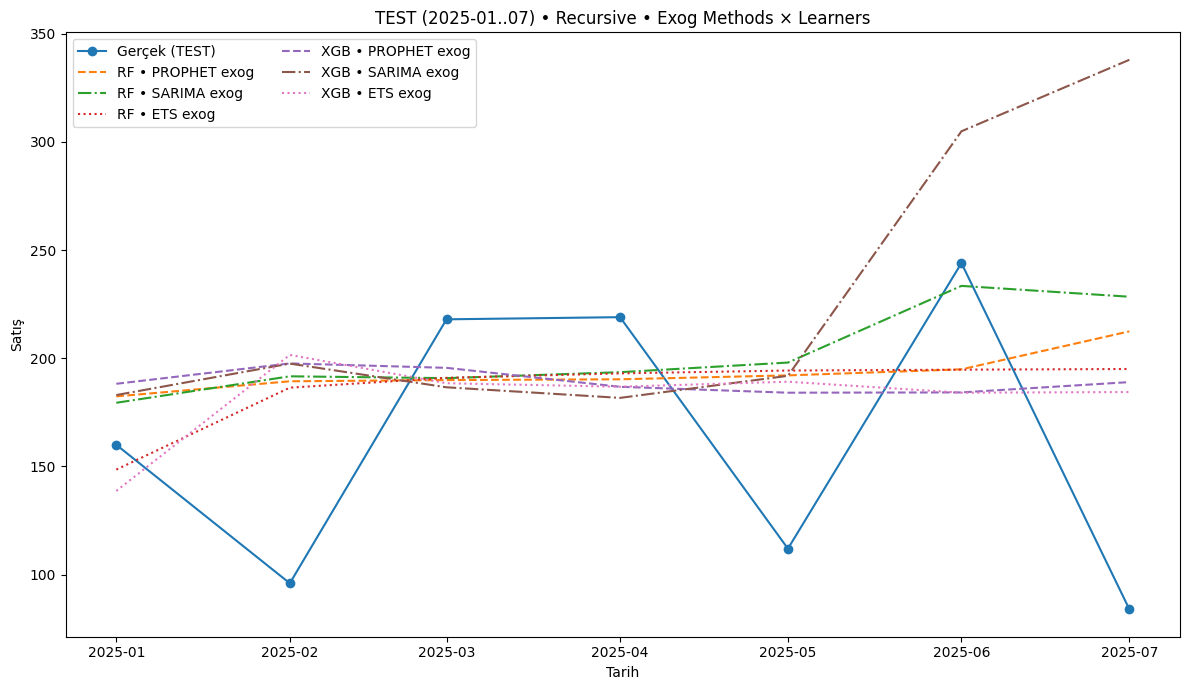

In [1]:
# ==============================================================
# Auto-Exog Forecast (Prophet / SARIMA / ETS) + RF & XGB Comparison
# Sızıntısız & Kausal final sürüm (HP araması yok)
# Features: orders, stock, orders_lag1/3, stock_lag1/3, y_lag1, orders_ratio, month, year
# Imputation:
#   - Train: 3 aylık merkezli rolling (+ffill/bfill)
#   - VAL/TEST/Recursive: kausal (yalnızca geçmişten doldur)
# Recursive TEST forecast (2025-01..07) with exog forecasts (fit only < TEST_START)
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")

RANDOM_STATE = 42

FEATURES = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

# ------------------ Metrics ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

# ------------------ Utilities ------------------
def ensure_ms_freq(df):
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def add_calendar(df):
    d = df.copy()
    d["year"]  = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def rolling_impute(s, causal=False):
    x = pd.to_numeric(s, errors="coerce")
    if causal:
        # yalnızca geçmişe bakarak doldur
        x = x.ffill()
        x = x.rolling(window=3, min_periods=1).mean()
        x = x.bfill()  # serinin başı için
    else:
        # train için merkezli kullanılabilir
        roll = x.rolling(window=3, center=True, min_periods=1).mean()
        x = x.where(~x.isna(), roll).ffill().bfill()
    return x

def build_lags_minimal(df):
    d = df.copy()
    if "orders" in d.columns and "stock" in d.columns:
        d["orders_ratio"] = d["orders"] / d["stock"].replace(0, np.nan)
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def prep_features(df_in, causal=False):
    d = add_calendar(df_in)
    d = build_lags_minimal(d)
    for col in ["orders","stock"]:
        if col in d.columns:
            d[col] = rolling_impute(d[col], causal=causal)
    for col in ["orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").ffill().bfill().fillna(0.0)
    for c in FEATURES:
        if c not in d.columns:
            d[c] = 0.0
    return d.replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------ Univariate exog forecasters (fit < TEST_START) ------------------
def forecast_univariate(df_col: pd.DataFrame, value_col: str, future_idx, method="prophet"):
    s_full = df_col[["ds", value_col]].dropna().sort_values("ds")
    s = s_full[s_full["ds"] < TEST_START].copy()  # <<< out-of-sample güvenliği
    if s.empty:
        return pd.DataFrame({"ds": future_idx, value_col: 0.0})
    steps = len(future_idx)

    if method == "prophet":
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
        m.fit(s.rename(columns={value_col:"y"}))
        fut = m.make_future_dataframe(periods=steps, freq="MS")
        fc  = m.predict(fut)[["ds","yhat"]].tail(steps)
        return fc.rename(columns={"yhat": value_col})

    elif method == "sarima":
        y = s.set_index("ds")[value_col]
        y.index.freq = "MS"
        # küçük bir grid (isteğe göre genişletilebilir)
        best, best_aic = None, np.inf
        for p in [0,1,2]:
            for q in [0,1,2]:
                for P in [0,1]:
                    for Q in [0,1]:
                        try:
                            res = SARIMAX(y, order=(p,1,q), seasonal_order=(P,1,Q,12),
                                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best = ((p,1,q), (P,1,Q,12))
                        except Exception:
                            pass
        if best is None:
            # fallback ETS
            method = "ets"
        else:
            model = SARIMAX(y, order=best[0], seasonal_order=best[1],
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            pred = model.get_forecast(steps=steps).predicted_mean
            return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), value_col: pred.values})

    if method == "ets":
        y = s.set_index("ds")[value_col]
        y.index.freq = "MS"
        try:
            ets = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
        except Exception:
            ets = ExponentialSmoothing(y, trend="add", seasonal=None).fit(optimized=True)
        pred = ets.forecast(steps)
        return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), value_col: pred.values})

def build_future_exog(df_all, future_idx, method="prophet"):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        if col in df_all.columns:
            fc = forecast_univariate(df_all[["ds", col]], col, future_idx, method=method)
            out = out.merge(fc, on="ds", how="left")
        else:
            out[col] = 0.0
    # causal imputasyon (geleceğe bakmadan)
    for c in ["orders","stock"]:
        out[c] = rolling_impute(out[c].astype(float), causal=True)
    return out

# ------------------ Recursive forward (causal) ------------------
def recursive_forward_predict(model, x_cols, hist_df, future_exog, start_ds, end_ds):
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")

    preds = []
    for ds in future_idx:
        tmp = prep_features(full.copy(), causal=True)  # <<< causal
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        y_hat = model.predict(X)[0]
        preds.append({"ds": ds, "yhat": y_hat})
        # autoregressive: bir sonraki ay için y_lag1 üretimi
        full.loc[full["ds"] == ds, "y"] = y_hat
        # exog güvenlik (causal imputasyon)
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute(full[c], causal=True)

    return pd.DataFrame(preds), full.loc[full["ds"].isin(future_idx)].copy()

# ------------------ Load raw & split FIRST ------------------
df_raw = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
df_raw = ensure_ms_freq(df_raw)

mask_train = (df_raw["ds"] < VAL_START)
mask_val   = (df_raw["ds"] >= VAL_START) & (df_raw["ds"] <= VAL_END)
mask_test  = (df_raw["ds"] >= TEST_START) & (df_raw["ds"] <= TEST_END)

train_df = prep_features(df_raw.loc[mask_train].copy(), causal=False)  # train: centered imputasyon OK
val_df   = prep_features(df_raw.loc[mask_val].copy(),   causal=True)   # val/test: causal
test_df  = prep_features(df_raw.loc[mask_test].copy(),  causal=True)

# ------------------ Learners (HP yok) ------------------
def fit_rf(train_df):
    model = RandomForestRegressor(
        n_estimators=500, max_depth=10, min_samples_split=2,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_df[FEATURES], train_df["y"])
    return model

def fit_xgb(train_df):
    model = XGBRegressor(
        n_estimators=500, learning_rate=0.08, max_depth=3,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.5,
        random_state=RANDOM_STATE
    )
    model.fit(train_df[FEATURES].to_numpy(), train_df["y"].to_numpy())
    return model

rf_model  = fit_rf(train_df)
xgb_model = fit_xgb(train_df)

# VAL direct (kontrol)
def eval_direct(model, name):
    y_hat = model.predict(val_df[FEATURES])
    mae, rmse, mape = mae_rmse_mape(val_df["y"], y_hat)
    return {"Split":"VAL", "Exog":"(direct)", "Model":name, "MAE":mae, "RMSE":rmse, "MAPE":mape}

results = []
results.append(eval_direct(rf_model,  "RF"))
results.append(eval_direct(xgb_model, "XGB"))

# ------------------ TEST recursive: exog methods ------------------
future_idx = pd.date_range(TEST_START, TEST_END, freq="MS")
hist_min = pd.concat([train_df, val_df], ignore_index=True)[["ds","y","orders","stock","month","year"]].copy()

for exog_method in ["prophet","sarima","ets"]:
    future_exog = build_future_exog(df_raw, future_idx, method=exog_method)

    # RF
    pred_rf, _ = recursive_forward_predict(rf_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END)
    eval_rf = test_df[["ds","y"]].merge(pred_rf, on="ds", how="left")
    mae, rmse, mape = mae_rmse_mape(eval_rf["y"], eval_rf["yhat"])
    results.append({"Split":"TEST", "Exog":exog_method.upper(), "Model":"RF", "MAE":mae, "RMSE":rmse, "MAPE":mape})

    # XGB
    pred_xgb, _ = recursive_forward_predict(xgb_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END)
    eval_xgb = test_df[["ds","y"]].merge(pred_xgb, on="ds", how="left")
    mae, rmse, mape = mae_rmse_mape(eval_xgb["y"], eval_xgb["yhat"])
    results.append({"Split":"TEST", "Exog":exog_method.upper(), "Model":"XGB", "MAE":mae, "RMSE":rmse, "MAPE":mape})

res_df = pd.DataFrame(results).sort_values(["Split","MAPE","MAE"]).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Sonuç Özeti ===")
print(res_df.to_string(index=False))

# ------------------ Plot — TEST kıyas ------------------
plt.figure(figsize=(12,7))
plt.plot(test_df["ds"], test_df["y"], "o-", label="Gerçek (TEST)")

styles = {"prophet":"--", "sarima":"-.", "ets":":"}
for ex in ["prophet","sarima","ets"]:
    future_exog = build_future_exog(df_raw, future_idx, method=ex)
    pred_rf, _ = recursive_forward_predict(rf_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END)
    plt.plot(pred_rf["ds"], pred_rf["yhat"], styles[ex], label=f"RF • {ex.upper()} exog")

for ex in ["prophet","sarima","ets"]:
    future_exog = build_future_exog(df_raw, future_idx, method=ex)
    pred_xgb, _ = recursive_forward_predict(xgb_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END)
    plt.plot(pred_xgb["ds"], pred_xgb["yhat"], styles[ex], label=f"XGB • {ex.upper()} exog")

plt.title("TEST (2025-01..07) • Recursive • Exog Methods × Learners")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(ncol=2); plt.tight_layout()
plt.show()
